# Canonical I-JEPA Manifest-to-Batch QC

This notebook validates the **canonical I-JEPA** data pipeline end-to-end (`pretraining.mode=canonical`).
Standard single-resolution masking (à la original I-JEPA) without cross-scale prediction.

## Goals
- Build `slide_id,wsi_path,mask_path` manifest by pairing files in `data/tcga-prad/wsi` and `data/tcga-prad/tissue-masks`.
- Rebuild slide metadata parquet and anchor catalog manifest with canonical scripts.
- Construct deterministic dataset samples and one collated batch via `make_canonical_loader`.
- Visualize sample images and mask token footprints.
- Run corruption/invariant checks and emit a pass/fail QC summary.

## Outline
1. Setup and imports
2. Config block
3. Manifest construction from local TCGA folders
4. Stage A: slide metadata parquet rebuild
5. Stage B: anchor catalog manifest rebuild
6. Anchor-level corruption guards
7. Stage C: sample-level inspection
8. Visual inspection: sample image
9. Stage D: collated-batch inspection
10. Mask non-leakage and token geometry diagnostics
11. QC summary (fail fast on critical checks)

In [15]:
from __future__ import annotations

import csv
import json
import random
import subprocess
import sys
from datetime import datetime
from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
import cv2
import hs2p
from PIL import Image

import pandas as pd
import wholeslidedata as wsd

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'ijepath').exists():
            return candidate
    raise RuntimeError('Could not find repository root containing .git and ijepath package.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from ijepath.datasets.canonical_loader_factory import make_canonical_loader
from ijepath.datasets.canonical_wsi_dataset import CanonicalWSIDataset
from ijepath.datasets.cross_resolution_wsi_dataset import IMAGENET_MEAN, IMAGENET_STD
from ijepath.utils.parquet import require_pyarrow
import canonical_plot_utils
from stagec_plot_utils import token_ids_to_map

SEED = 21
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'REPO_ROOT={REPO_ROOT}')
print(f'NOTEBOOK_DIR={NOTEBOOK_DIR}')
print(f'KERNEL_PYTHON={sys.executable}')
print(f'SEED={SEED}')

REPO_ROOT=/data/pathology/projects/clement/code/ijepath
NOTEBOOK_DIR=/data/pathology/projects/clement/code/ijepath/notebooks
KERNEL_PYTHON=/usr/bin/python
SEED=21


## Config Block

Fixed defaults used by this notebook. Canonical params are read from `RUN_YAML`; `spacing_tolerance` from `PROFILE_YAML`.

In [16]:
EXPECTED_PYTHON = sys.executable

WSI_DIR = Path('../data/tcga-prad/wsi').resolve()
MASK_DIR = Path('../data/tcga-prad/tissue-masks').resolve()
PROFILE_YAML = Path('../configs/profiles/canonical_20x_256_224.yaml').resolve()
RUN_YAML = Path('../configs/runs/canonical_pathorob_camelyon.yaml').resolve()
WORK_DIR = Path('../output/notebook-artifacts/canonical-manifest-to-batch-qc').resolve()

BATCH_SIZE = 2
NUM_WORKERS = 0
WSI_BACKEND = 'openslide'

MANIFEST_DIR = WORK_DIR / 'manifests'
INDEX_DIR = WORK_DIR / 'indexes'
MPL_DIR = WORK_DIR / 'mpl'
for p in (MANIFEST_DIR, INDEX_DIR, MPL_DIR):
    p.mkdir(parents=True, exist_ok=True)

MANIFEST_CSV = MANIFEST_DIR / 'slides_with_tissue_masks.csv'
SLIDE_METADATA_PARQUET = INDEX_DIR / 'slide_metadata.parquet'
SLIDE_REPORT_CSV = INDEX_DIR / 'slide_metadata_build_report.csv'
ANCHOR_MANIFEST_JSON = INDEX_DIR / 'anchor_catalog_manifest.json'
ANCHOR_REPORT_CSV = INDEX_DIR / 'anchor_catalog_build_report.csv'

QC_RESULTS: list[dict[str, object]] = []

# Read run YAML to extract canonical params
run_cfg = yaml.safe_load(RUN_YAML.read_text(encoding='utf-8'))
canonical_cfg = run_cfg['canonical']

input_mpp = float(canonical_cfg['input_mpp'])
source_tile_size_px = int(canonical_cfg['source_tile_size_px'])
crop_size_px = int(canonical_cfg['crop_size_px'])
enc_mask_scale = tuple(float(x) for x in canonical_cfg['enc_mask_scale'])
pred_mask_scale = tuple(float(x) for x in canonical_cfg['pred_mask_scale'])
aspect_ratio = tuple(float(x) for x in canonical_cfg['aspect_ratio'])
num_enc_masks = int(canonical_cfg['num_enc_masks'])
num_pred_masks = int(canonical_cfg['num_pred_masks'])
min_keep = int(canonical_cfg['min_keep'])

PATCH_SIZE = int(run_cfg['meta']['patch_size'])

# Read profile YAML for spacing_tolerance only
profile_cfg = yaml.safe_load(PROFILE_YAML.read_text(encoding='utf-8'))
spacing_tolerance = float(profile_cfg.get('spacing_tolerance', 0.05))


def record_check(name: str, passed: bool, details: str = '') -> None:
    row = {'check': name, 'passed': bool(passed), 'details': str(details)}
    QC_RESULTS.append(row)
    state = 'PASS' if passed else 'FAIL'
    print(f'[{state}] {name}: {details}')
    if not passed:
        raise AssertionError(f'{name} failed: {details}')


def run_cmd(cmd: list[str]) -> str:
    printable = ' '.join(cmd)
    print(f'\n$ {printable}')
    try:
        proc = subprocess.run(
            cmd,
            cwd=str(REPO_ROOT),
            check=True,
            text=True,
            capture_output=True,
        )
    except subprocess.CalledProcessError as exc:
        if exc.stdout:
            print(exc.stdout.strip())
        if exc.stderr:
            print(exc.stderr.strip())
        raise
    if proc.stdout.strip():
        print(proc.stdout.strip())
    if proc.stderr.strip():
        print(proc.stderr.strip())
    return proc.stdout


def tensor_to_rgb_uint8(t: torch.Tensor) -> np.ndarray:
    arr = t.detach().cpu().numpy().transpose(1, 2, 0)
    arr = (arr * IMAGENET_STD[None, None, :]) + IMAGENET_MEAN[None, None, :]
    arr = np.clip(arr, 0.0, 1.0)
    return (arr * 255.0).astype(np.uint8)


for p in (WSI_DIR, MASK_DIR, PROFILE_YAML, RUN_YAML):
    record_check(f'Path exists: {p.name}', p.exists(), str(p))

print(f'WORK_DIR={WORK_DIR}')
print(f'input_mpp={input_mpp}, source_tile_size_px={source_tile_size_px}, crop_size_px={crop_size_px}')
print(f'PATCH_SIZE={PATCH_SIZE}')
print(f'enc_mask_scale={enc_mask_scale}, pred_mask_scale={pred_mask_scale}')
print(f'num_enc_masks={num_enc_masks}, num_pred_masks={num_pred_masks}, min_keep={min_keep}')

[PASS] Path exists: wsi: /data/pathology/projects/clement/code/ijepath/data/tcga-prad/wsi
[PASS] Path exists: tissue-masks: /data/pathology/projects/clement/code/ijepath/data/tcga-prad/tissue-masks
[PASS] Path exists: canonical_20x_256_224.yaml: /data/pathology/projects/clement/code/ijepath/configs/profiles/canonical_20x_256_224.yaml
[PASS] Path exists: canonical_pathorob_camelyon.yaml: /data/pathology/projects/clement/code/ijepath/configs/runs/canonical_pathorob_camelyon.yaml
WORK_DIR=/data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc
input_mpp=0.5, source_tile_size_px=256, crop_size_px=224
PATCH_SIZE=16
enc_mask_scale=(0.85, 1.0), pred_mask_scale=(0.15, 0.2)
num_enc_masks=1, num_pred_masks=4, min_keep=16


## Manifest Construction from Directories

Pair `*.tif` files by stem and fail fast on mismatches.

In [17]:
wsi_by_stem = {p.stem: p.resolve() for p in sorted(WSI_DIR.glob('*.tif'))}
mask_by_stem = {p.stem: p.resolve() for p in sorted(MASK_DIR.glob('*.tif'))}

common_ids = sorted(set(wsi_by_stem) & set(mask_by_stem))
missing_masks = sorted(set(wsi_by_stem) - set(mask_by_stem))
orphan_masks = sorted(set(mask_by_stem) - set(wsi_by_stem))

record_check('At least one matched slide/mask pair', len(common_ids) > 0, f'matched={len(common_ids)}')
record_check('No WSI without mask', len(missing_masks) == 0, str(missing_masks))
record_check('No orphan mask without WSI', len(orphan_masks) == 0, str(orphan_masks))

with MANIFEST_CSV.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['slide_id', 'wsi_path', 'mask_path'])
    writer.writeheader()
    for slide_id in common_ids:
        writer.writerow(
            {
                'slide_id': slide_id,
                'wsi_path': str(wsi_by_stem[slide_id]),
                'mask_path': str(mask_by_stem[slide_id]),
            }
        )

record_check('Manifest CSV written', MANIFEST_CSV.exists(), str(MANIFEST_CSV))

manifest_rows = []
with MANIFEST_CSV.open('r', newline='', encoding='utf-8') as f:
    manifest_rows = list(csv.DictReader(f))

record_check(
    'Manifest row count matches matched ids',
    len(manifest_rows) == len(common_ids),
    f'rows={len(manifest_rows)} matched={len(common_ids)}',
)

fingerprints = []
for row in manifest_rows:
    wsi = Path(row['wsi_path'])
    mask = Path(row['mask_path'])
    fingerprints.append(
        {
            'slide_id': row['slide_id'],
            'wsi_size_bytes': int(wsi.stat().st_size),
            'wsi_mtime_iso': datetime.fromtimestamp(wsi.stat().st_mtime).isoformat(timespec='seconds'),
            'mask_size_bytes': int(mask.stat().st_size),
            'mask_mtime_iso': datetime.fromtimestamp(mask.stat().st_mtime).isoformat(timespec='seconds'),
        }
    )

print(f'Manifest path: {MANIFEST_CSV}')
if pd is not None:
    display(pd.DataFrame(manifest_rows))
    display(pd.DataFrame(fingerprints))
else:
    print(manifest_rows)
    print(fingerprints)

[PASS] At least one matched slide/mask pair: matched=4
[PASS] No WSI without mask: []
[PASS] No orphan mask without WSI: []
[PASS] Manifest CSV written: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/manifests/slides_with_tissue_masks.csv
[PASS] Manifest row count matches matched ids: rows=4 matched=4
Manifest path: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/manifests/slides_with_tissue_masks.csv


,slide_id,wsi_path,mask_path
0,TCGA-HC-8257,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...
1,TCGA-HC-8260,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...
2,TCGA-HC-8265,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...
3,TCGA-HC-A8D1,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...


,slide_id,wsi_size_bytes,wsi_mtime_iso,mask_size_bytes,mask_mtime_iso
0,TCGA-HC-8257,90395228,2026-02-08T02:01:35,191624,2026-02-17T14:07:13
1,TCGA-HC-8260,80104764,2026-02-08T02:02:23,183609,2026-02-17T14:05:09
2,TCGA-HC-8265,84550234,2026-02-08T02:02:06,107677,2026-02-17T14:00:01
3,TCGA-HC-A8D1,70518008,2026-02-08T02:01:50,106046,2026-02-17T14:05:44


## Stage A: Rebuild Slide Metadata Parquet

Run `scripts/build_slide_metadata_index_from_manifest.py` and validate report rows.

In [18]:
run_cmd(
    [
        str(EXPECTED_PYTHON),
        str(REPO_ROOT / 'scripts/build_slide_metadata_index_from_manifest.py'),
        '--manifest', str(MANIFEST_CSV),
        '--output', str(SLIDE_METADATA_PARQUET),
        '--report', str(SLIDE_REPORT_CSV),
        '--backend', WSI_BACKEND,
    ]
)

record_check('Slide metadata parquet exists', SLIDE_METADATA_PARQUET.exists(), str(SLIDE_METADATA_PARQUET))
record_check('Slide metadata report exists', SLIDE_REPORT_CSV.exists(), str(SLIDE_REPORT_CSV))

with SLIDE_REPORT_CSV.open('r', newline='', encoding='utf-8') as f:
    slide_report_rows = list(csv.DictReader(f))
failed_slides = [r for r in slide_report_rows if str(r.get('status')) != 'ok']
record_check('All slide metadata rows succeeded', len(failed_slides) == 0, f'failed={len(failed_slides)}')

_, _, ds = require_pyarrow()
slide_table = ds.dataset(str(SLIDE_METADATA_PARQUET), format='parquet').to_table()
print('slide_metadata schema:')
print(slide_table.schema)
print('slide_metadata rows:', slide_table.num_rows)
preview_rows = slide_table.slice(0, min(3, slide_table.num_rows)).to_pylist()
if pd is not None:
    display(pd.DataFrame(preview_rows))
else:
    print(preview_rows)


$ /usr/bin/python /data/pathology/projects/clement/code/ijepath/scripts/build_slide_metadata_index_from_manifest.py --manifest /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/manifests/slides_with_tissue_masks.csv --output /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/slide_metadata.parquet --report /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/slide_metadata_build_report.csv --backend openslide
wrote_index=/data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/slide_metadata.parquet
wrote_report=/data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/slide_metadata_build_report.csv
slides_ok=4 slides_failed=0
Processing slides: 100%|██████████| 4/4 [00:00<00:00, 65.08slide/s]
[PASS] Slide meta

,slide_id,wsi_path,mask_path,status,error,wsi_level0_width,wsi_level0_height,wsi_level0_spacing_mpp,wsi_shapes,wsi_spacings_mpp,mask_level0_width,mask_level0_height,mask_level0_spacing_mpp,mask_shapes,mask_spacings_mpp,mask_to_wsi_scale_x,mask_to_wsi_scale_y
0,TCGA-HC-8257,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,ok,None,26112,31744,0.252,"[[26112, 31744], [6528, 7936], [1632, 1984], [...","[0.25200000393750005, 1.0080000157500002, 4.03...",6528,7936,1.008,"[[6528, 7936], [3264, 3968], [1632, 1984], [81...","[1.0080000157500002, 2.0160000315000004, 4.032...",4.0,4.0
1,TCGA-HC-8260,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,ok,None,31232,18944,0.252,"[[31232, 18944], [7808, 4736], [1952, 1184], [...","[0.25200000393750005, 1.0080000157500002, 4.03...",7808,4736,1.008,"[[7808, 4736], [3904, 2368], [1952, 1184], [97...","[1.0080000157500002, 2.0160000315000004, 4.032...",4.0,4.0
2,TCGA-HC-8265,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,ok,None,23552,18944,0.252,"[[23552, 18944], [5888, 4736], [1472, 1184], [...","[0.25200000393750005, 1.0080000157500002, 4.03...",5888,4736,1.008,"[[5888, 4736], [2944, 2368], [1472, 1184], [73...","[1.0080000157500002, 2.0160000315000004, 4.032...",4.0,4.0


## Stage B: Rebuild Anchor Catalog Manifest

Run `scripts/build_valid_context_anchor_catalog.py` with the canonical profile and validate manifest/shards consistency.

In [19]:
run_cmd(
    [
        str(EXPECTED_PYTHON),
        str(REPO_ROOT / 'scripts/build_valid_context_anchor_catalog.py'),
        '--slide-index', str(SLIDE_METADATA_PARQUET),
        '--profile', str(PROFILE_YAML),
        '--output', str(ANCHOR_MANIFEST_JSON),
        '--backend', WSI_BACKEND,
        '--workers', '1',
    ]
)

record_check('Anchor manifest JSON exists', ANCHOR_MANIFEST_JSON.exists(), str(ANCHOR_MANIFEST_JSON))
record_check('Anchor build report exists', ANCHOR_REPORT_CSV.exists(), str(ANCHOR_REPORT_CSV))

anchor_manifest = json.loads(ANCHOR_MANIFEST_JSON.read_text(encoding='utf-8'))
anchor_shards = list(anchor_manifest.get('anchor_shards', []))
total_anchors = int(anchor_manifest.get('total_anchors', 0))

record_check('Anchor manifest has non-zero anchors', total_anchors > 0, f'total_anchors={total_anchors}')
record_check('Anchor manifest has shard entries', len(anchor_shards) > 0, f'shards={len(anchor_shards)}')

rows_from_manifest = int(sum(int(s.get('rows', 0)) for s in anchor_shards))
record_check(
    'Shard row sum equals manifest total_anchors',
    rows_from_manifest == total_anchors,
    f'shard_rows={rows_from_manifest} total={total_anchors}',
)

missing_shards = [str(Path(s['path'])) for s in anchor_shards if not Path(s['path']).exists()]
record_check('All shard files exist on disk', len(missing_shards) == 0, str(missing_shards))

with ANCHOR_REPORT_CSV.open('r', newline='', encoding='utf-8') as f:
    anchor_report_rows = list(csv.DictReader(f))
failed_anchor_slides = [r for r in anchor_report_rows if str(r.get('status')) != 'ok']
record_check(
    'All anchor report slide statuses are ok',
    len(failed_anchor_slides) == 0,
    f'failed={len(failed_anchor_slides)}',
)

stratum_counts = anchor_manifest.get('stratum_counts', {})
print('Anchor profile:', anchor_manifest.get('profile', {}))
print('Sampling stratum key:', anchor_manifest.get('sampling_stratum_key'))
print('Stratum counts:', stratum_counts)
if pd is not None:
    display(pd.DataFrame(anchor_report_rows))


$ /usr/bin/python /data/pathology/projects/clement/code/ijepath/scripts/build_valid_context_anchor_catalog.py --slide-index /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/slide_metadata.parquet --profile /data/pathology/projects/clement/code/ijepath/configs/profiles/canonical_20x_256_224.yaml --output /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/anchor_catalog_manifest.json --backend openslide --workers 1
wrote_anchor_manifest=/data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/anchor_catalog_manifest.json
wrote_report=/data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/anchor_catalog_build_report.csv
slides total=4
anchors total=4,014
shards total=4
Processing slides: 100%|██████████| 4/4 [00:03<00:00,  1.16slide/s]
[PASS] Anchor manifest J

,slide_id,status,reason,anchors
0,TCGA-HC-8257,ok,,972
1,TCGA-HC-8260,ok,,1046
2,TCGA-HC-8265,ok,,1069
3,TCGA-HC-A8D1,ok,,927


## Anchor-Level Integrity Checks (Corruption Guards)

Read first shard parquet and verify required fields, numeric finiteness, tissue range, and path existence.

In [20]:
import pyarrow.parquet as pq

first_shard_path = Path(anchor_shards[0]['path']).resolve()
anchor_table = pq.read_table(str(first_shard_path))
anchor_rows = anchor_table.to_pylist()
record_check('First anchor shard has rows', anchor_table.num_rows > 0, f'rows={anchor_table.num_rows}')

required_cols = {
    'anchor_id',
    'slide_id',
    'wsi_path',
    'mask_path',
    'center_x_level0',
    'center_y_level0',
    'tissue_fraction',
    'context_mpp',
    'target_mpp',
    'context_fov_um',
    'target_fov_um',
    'targets_per_context',
}
missing_cols = sorted(required_cols - set(anchor_table.column_names))
record_check('Required anchor columns present', len(missing_cols) == 0, str(missing_cols))

tissue = np.asarray(anchor_table.column('tissue_fraction').to_numpy(), dtype=np.float64)
record_check('All tissue fractions finite', bool(np.isfinite(tissue).all()), '')
record_check(
    'All tissue fractions in [0,1]',
    bool(((tissue >= 0.0) & (tissue <= 1.0)).all()),
    f'min={float(tissue.min()):.5f} max={float(tissue.max()):.5f}',
)

numeric_cols = [
    'center_x_level0',
    'center_y_level0',
    'context_mpp',
    'target_mpp',
    'context_fov_um',
    'target_fov_um',
    'targets_per_context',
]
for col in numeric_cols:
    vals = np.asarray(anchor_table.column(col).to_numpy(), dtype=np.float64)
    record_check(f'Column finite: {col}', bool(np.isfinite(vals).all()), col)

unique_wsi_paths = sorted({str(r['wsi_path']) for r in anchor_rows})
unique_mask_paths = sorted({str(r['mask_path']) for r in anchor_rows})
missing_wsi_paths = [p for p in unique_wsi_paths if not Path(p).exists()]
missing_mask_paths = [p for p in unique_mask_paths if not Path(p).exists()]
record_check('All anchor shard WSI paths exist', len(missing_wsi_paths) == 0, str(missing_wsi_paths))
record_check('All anchor shard mask paths exist', len(missing_mask_paths) == 0, str(missing_mask_paths))

if pd is not None:
    display(pd.DataFrame(anchor_rows[:5]))
else:
    print(anchor_rows[:2])

[PASS] First anchor shard has rows: rows=972
[PASS] Required anchor columns present: []
[PASS] All tissue fractions finite: 
[PASS] All tissue fractions in [0,1]: min=0.20557 max=1.00000
[PASS] Column finite: center_x_level0: center_x_level0
[PASS] Column finite: center_y_level0: center_y_level0
[PASS] Column finite: context_mpp: context_mpp
[PASS] Column finite: target_mpp: target_mpp
[PASS] Column finite: context_fov_um: context_fov_um
[PASS] Column finite: target_fov_um: target_fov_um
[PASS] Column finite: targets_per_context: targets_per_context
[PASS] All anchor shard WSI paths exist: []
[PASS] All anchor shard mask paths exist: []


,anchor_id,slide_id,profile_id,stratum_id,wsi_path,mask_path,center_x_level0,center_y_level0,center_x_mask,center_y_mask,...,target_mpp,context_fov_um,target_fov_um,targets_per_context,target_margin_um,target_margin_context_px,context_size_px,target_size_context_px,anchor_overlap_fraction,spacing_tolerance
0,TCGA-HC-8257_0000000,TCGA-HC-8257,canonical_0p5mpp_128_32,unknown,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,22604,760,5651,190,...,0.5,128.0,32.0,4,4.0,32,256,64,0.0,0.05
1,TCGA-HC-8257_0000001,TCGA-HC-8257,canonical_0p5mpp_128_32,unknown,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,23112,760,5778,190,...,0.5,128.0,32.0,4,4.0,32,256,64,0.0,0.05
2,TCGA-HC-8257_0000002,TCGA-HC-8257,canonical_0p5mpp_128_32,unknown,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,23620,760,5905,190,...,0.5,128.0,32.0,4,4.0,32,256,64,0.0,0.05
3,TCGA-HC-8257_0000003,TCGA-HC-8257,canonical_0p5mpp_128_32,unknown,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,24128,760,6032,190,...,0.5,128.0,32.0,4,4.0,32,256,64,0.0,0.05
4,TCGA-HC-8257_0000004,TCGA-HC-8257,canonical_0p5mpp_128_32,unknown,/data/pathology/projects/clement/code/ijepath/...,/data/pathology/projects/clement/code/ijepath/...,24636,760,6159,190,...,0.5,128.0,32.0,4,4.0,32,256,64,0.0,0.05


In [21]:
# ── Per-slide lookups and anchor row index (shared by Stage C and Stage D) ────
_slide_meta_rows = ds.dataset(str(SLIDE_METADATA_PARQUET), format='parquet').to_table().to_pylist()
wsi_l0_mpp_by_slide = {str(r['slide_id']): float(r['wsi_level0_spacing_mpp']) for r in _slide_meta_rows}
mask_spacings_by_slide = {
    str(r['slide_id']): [float(s) for s in r['mask_spacings_mpp']]
    for r in _slide_meta_rows
}
# Pixel-space scale factors: wsi_level0_width / mask_level0_width (and same for y).
# Used to convert WSI level-0 pixel coords → mask level-0 pixel coords.
mask_scale_x_by_slide = {str(r['slide_id']): float(r['mask_to_wsi_scale_x']) for r in _slide_meta_rows}
mask_scale_y_by_slide = {str(r['slide_id']): float(r['mask_to_wsi_scale_y']) for r in _slide_meta_rows}

anchor_data_by_id: dict[str, dict] = {}
for shard_info in anchor_shards:
    tbl = pq.read_table(
        str(Path(shard_info['path'])),
        columns=['anchor_id', 'slide_id', 'wsi_path', 'mask_path',
                 'center_x_level0', 'center_y_level0', 'tissue_fraction'],
    )
    for row in tbl.to_pylist():
        anchor_data_by_id[str(row['anchor_id'])] = row

print(f'Loaded {len(anchor_data_by_id)} anchor rows | {len(wsi_l0_mpp_by_slide)} slides')


def compute_tissue_token_map(
    img_tensor: torch.Tensor, grid_h: int, grid_w: int, patch_size: int
) -> np.ndarray:
    """Per-token tissue proxy (inverted luminance): white background → 0, stained tissue → 1."""
    img_f = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img_f = img_f * IMAGENET_STD + IMAGENET_MEAN
    img_f = np.clip(img_f, 0.0, 1.0)
    luminance = 0.299 * img_f[..., 0] + 0.587 * img_f[..., 1] + 0.114 * img_f[..., 2]
    tissue_proxy = (1.0 - luminance).astype(np.float32)
    token_tissue = np.zeros((grid_h, grid_w), dtype=np.float32)
    for gy in range(grid_h):
        for gx in range(grid_w):
            py0, px0 = gy * patch_size, gx * patch_size
            token_tissue[gy, gx] = tissue_proxy[py0:py0 + patch_size, px0:px0 + patch_size].mean()
    return token_tissue

class SegmentationParameters(NamedTuple):
    """
    Parameters for filtering contours.
    """

    downsample: int  # dowsample factor for loading segmentation mask
    sthresh: int  # segmentation threshold (positive integer, using a higher threshold leads to less foreground and more background detection) (not used when use_otsu=True)
    sthresh_up: int  # upper threshold value for scaling the binary mask
    mthresh: int  # median filter size (positive, odd integer)
    close: int  # additional morphological closing to apply following initial thresholding (positive integer)
    use_otsu: bool  # whether to use Otsu's method for thresholding
    use_hsv: bool  # whether to use HSV thresholding

class SamplingParameters(NamedTuple):
    """
    Parameters for sampling.
    """

    pixel_mapping: dict[
        str, int
    ]  # mapping from annotation names to pixel values in the annotation mask
    color_mapping: dict[
        str, list[int] | None
    ]  # mapping from annotation names to RGB color codes for overlaying
    tissue_percentage: dict[
        str, float | None
    ]  # minimum percentage of tile coverage for each category required to sample tiles


seg_params = SegmentationParameters(
    downsample=16,
    sthresh=15,
    sthresh_up=255,
    mthresh=5,
    close=5,
    use_otsu=False,
    use_hsv=False,
)

sampling_params = SamplingParameters(
    pixel_mapping={
        'background': 0,
        'tissue': 1,
    },
    color_mapping={
        'background': [255, 255, 255],
        'tissue': [255, 0, 0],
    },
    tissue_percentage={
        'background': None,
        'tissue': 0.5,
    },
)

def load_source_tile_and_mask(
    wsi_path: str,
    mask_path: str,
    center_x_l0: int,
    center_y_l0: int,
    source_tile_size_px: int,
    input_mpp: float,
    wsi_l0_mpp: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Read source tile (RGB) and binary tissue mask at the anchor center.

    Returns (tile_rgb, binary_mask) both shaped (out_size, out_size).
    binary_mask: 1 where tissue, 0 elsewhere.

    Coordinate handling
    -------------------
    All coordinates stay in pixel space throughout.

    WSI tile: source_tile_size_px pixels at input_mpp → tile_l0_px WSI level-0 pixels.
    Mask overlay:
      1. Find closest mask level by mpp distance.
      2. Convert anchor center WSI level-0 → mask level-0 via pixel ratio
         (mask_to_wsi_scale_x = wsi_l0_width / mask_l0_width).
      3. Compute patch size at chosen level from WSI l0 pixel count and level
         downsample factors (from OpenSlide level_dimensions, not mpp).
      4. Upsample with NEAREST to keep mask binary.
    """
    # ── WSI RGB tile ──────────────────────────────────────────────────────────
    tile_l0_px = int(round(source_tile_size_px * input_mpp / wsi_l0_mpp))
    x0_wsi = center_x_l0 - tile_l0_px // 2
    y0_wsi = center_y_l0 - tile_l0_px // 2

    # retrieve tile
    wsi = hs2p.wsi.WholeSlideImage(
        path=Path(wsi_path),
        mask_path=Path(mask_path),
        backend=WSI_BACKEND,
        segment_params=seg_params,
        sampling_params=sampling_params,
    )
    tile_level, is_within_tolerance = wsi.get_best_level_for_spacing(
        target_spacing=input_mpp,
        tolerance=spacing_tolerance,
    )
    effective_spacing = wsi.get_level_spacing(tile_level)
    tile_arr = wsi.get_tile(
        x0_wsi,
        y0_wsi,
        tile_l0_px,
        tile_l0_px,
        spacing=effective_spacing,
    )
    tile = Image.fromarray(tile_arr).convert("RGB")
    if source_tile_size_px != tile.size[0]: 
        tile = tile.resize((source_tile_size_px, source_tile_size_px))

    # retrieve mask
    mask = hs2p.wsi.WholeSlideImage(
        path=Path(mask_path),
        backend=WSI_BACKEND,
        segment=False,
    )
    mask_spacing = mask.get_level_spacing(0)
    # map x0,y0 from WSI level-0 to mask level-0
    x0_mask_l0 = int(round(x0_wsi * wsi_l0_mpp / mask_spacing))
    y0_mask_l0 = int(round(y0_wsi * wsi_l0_mpp / mask_spacing))
    tile_l0_mask_px = int(round(tile_l0_px * wsi_l0_mpp / mask_spacing))
    mask_tile_arr = mask.get_tile(
        x0_mask_l0,
        y0_mask_l0,
        tile_l0_mask_px,
        tile_l0_mask_px,
        spacing=mask_spacing,
    )
    # compute tissue coverage
    tissue_pct = (mask_tile_arr > 0).sum() / mask_tile_arr.size
    # upsample mask tile to match output size, using nearest neighbor to preserve binary nature
    mask_tile = Image.fromarray(mask_tile_arr).convert("L")
    if source_tile_size_px != mask_tile.size[0]: 
        mask_tile = mask_tile.resize((source_tile_size_px, source_tile_size_px), resample=Image.NEAREST)

    return tile, mask_tile, tissue_pct

Loaded 4014 anchor rows | 4 slides


## Stage C: Dataset Sample Inspection

Instantiate `CanonicalWSIDataset` directly; fetch deterministic samples and verify shape, finiteness, and metadata keys.

Note: PyTorch's global RNG is seeded with `SEED + index` before each access to make `RandomResizedCrop` deterministic.

In [22]:
sample_dataset = CanonicalWSIDataset(
    anchor_catalog_manifest=str(ANCHOR_MANIFEST_JSON),
    input_mpp=input_mpp,
    source_tile_size_px=source_tile_size_px,
    crop_size_px=crop_size_px,
    patch_size=PATCH_SIZE,
    seed=SEED,
    spacing_tolerance=spacing_tolerance,
    backend=WSI_BACKEND,
)

print('len(dataset):', len(sample_dataset))
print('crop_size_px:', sample_dataset.crop_size_px)
print('source_tile_size_px:', sample_dataset.source_tile_size_px)

# Seed per-index so RandomResizedCrop is deterministic for the same index
torch.manual_seed(SEED + 0)
sample0 = sample_dataset[0]
torch.manual_seed(SEED + 1)
sample1 = sample_dataset[1]
torch.manual_seed(SEED + 0)
sample0_repeat = sample_dataset[0]

record_check(
    'Deterministic sample[0] image tensor',
    bool(torch.allclose(sample0['image'], sample0_repeat['image'])),
    'sample0 vs sample0_repeat',
)

for idx, sample in enumerate([sample0, sample1]):
    img = sample['image']
    m = sample['sample_metadata']

    record_check(
        f'sample[{idx}] image shape',
        img.ndim == 3 and tuple(img.shape) == (3, crop_size_px, crop_size_px),
        str(tuple(img.shape)),
    )
    record_check(f'sample[{idx}] image finite', bool(torch.isfinite(img).all().item()), '')

    required_meta = {
        'slide_id',
        'anchor_id',
        'requested_input_mpp',
        'source_input_mpp',
        'source_resolution_mode',
        'model_crop_size_px',
    }
    missing_meta = sorted(required_meta - set(m.keys()))
    record_check(f'sample[{idx}] required metadata keys', len(missing_meta) == 0, str(missing_meta))

print('sample0 metadata keys:', sorted(sample0['sample_metadata'].keys()))

len(dataset): 4014
crop_size_px: 224
source_tile_size_px: 256
[PASS] Deterministic sample[0] image tensor: sample0 vs sample0_repeat
[PASS] sample[0] image shape: (3, 224, 224)
[PASS] sample[0] image finite: 
[PASS] sample[0] required metadata keys: []
[PASS] sample[1] image shape: (3, 224, 224)
[PASS] sample[1] image finite: 
[PASS] sample[1] required metadata keys: []
sample0 metadata keys: ['anchor_id', 'anchor_stream_batch_id', 'anchor_stream_batch_size', 'anchor_stream_row_in_batch', 'anchor_stream_shard_path', 'color_jitter_strength', 'crop_scale_max', 'crop_scale_min', 'dataset_pass_index', 'horizontal_flip_prob', 'model_crop_size_px', 'reader_cache_event', 'reader_cache_evictions_on_event', 'reader_cache_evictions_total', 'reader_cache_hit', 'reader_cache_hits_total', 'reader_cache_miss', 'reader_cache_misses_total', 'reader_cache_open_slides', 'requested_input_mpp', 'slide_id', 'source_input_mpp', 'source_resolution_mode', 'source_tile_size_px_at_effective_spacing', 'source_ti

## Visual Inspection: Sample Image

Denormalize and display `sample0['image']`; print metadata table.

source_tile.size=(256, 256)
mask_tile.size=(256, 256)
0.67518 vs anchor_row0=0.66211
[PASS] Anchor tissue fraction matches readback: 0.67518 vs anchor_row0=0.66211
[PASS] Source tile size correct: (256, 256) vs expected (256, 256)
np.unique(mask_arr)=array([0, 1], dtype=uint8)
green_rgba0.shape=(256, 256, 4)
mask_arr.shape=(256, 256)


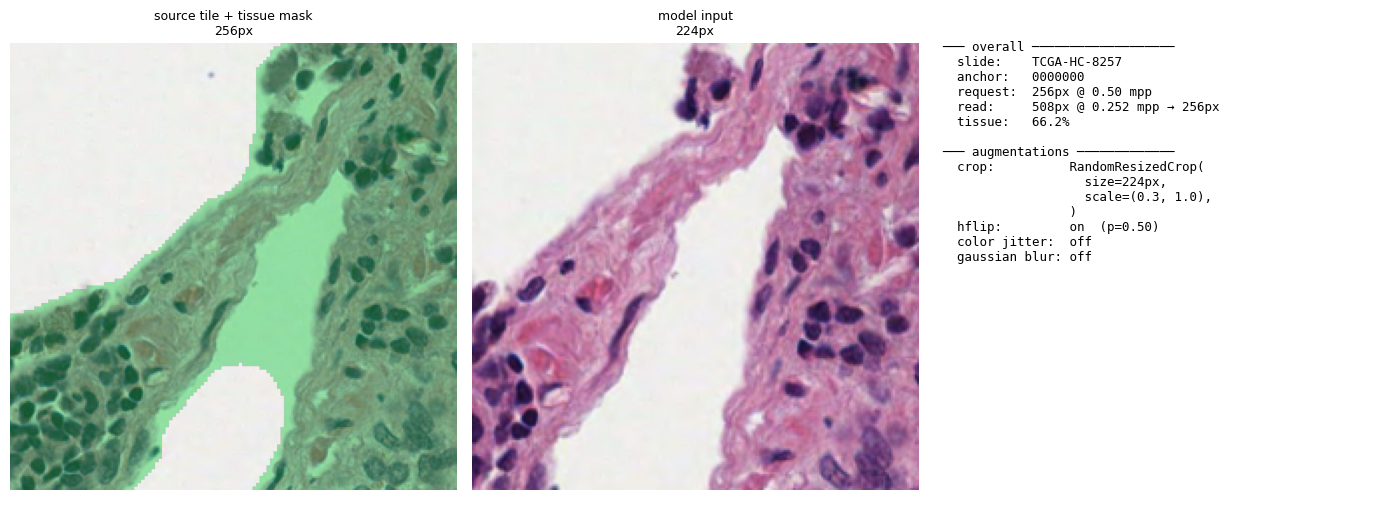

[PASS] Sample visualization written: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/mpl/sample0_canonical.png


In [24]:
img_rgb = tensor_to_rgb_uint8(sample0['image'])
meta0 = sample0['sample_metadata']

anchor_row0 = anchor_data_by_id[meta0['anchor_id']]
source_tile, mask_tile, tissue_pct = load_source_tile_and_mask(
    wsi_path=str(anchor_row0['wsi_path']),
    mask_path=str(anchor_row0['mask_path']),
    center_x_l0=int(anchor_row0['center_x_level0']),
    center_y_l0=int(anchor_row0['center_y_level0']),
    source_tile_size_px=source_tile_size_px,
    input_mpp=input_mpp,
    wsi_l0_mpp=wsi_l0_mpp_by_slide[anchor_row0['slide_id']],
)
print(f"{source_tile.size=}")
print(f"{mask_tile.size=}")
print(f'{tissue_pct:=.5f} vs anchor_row0={anchor_row0["tissue_fraction"]:.5f}')
record_check(
    'Anchor tissue fraction matches readback',
    abs(tissue_pct - float(anchor_row0['tissue_fraction'])) < 0.05,
    f'{tissue_pct:.5f} vs anchor_row0={anchor_row0["tissue_fraction"]:.5f}',
)
record_check(
    'Source tile size correct',
    source_tile.size == (source_tile_size_px, source_tile_size_px),
    f'{source_tile.size} vs expected {(source_tile_size_px, source_tile_size_px)}',
)

green_rgba0 = np.zeros((*source_tile.size, 4), dtype=np.uint8)
mask_arr = np.array(mask_tile)
print(f"{np.unique(mask_arr)=}")
print(f"{green_rgba0.shape=}")
print(f"{mask_arr.shape=}")
green_rgba0[mask_arr > 0] = [0, 200, 50, 100]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

req_sz = int(meta0['source_tile_size_px_requested'])
req_mpp = float(meta0['requested_input_mpp'])
src_sz = int(meta0['source_tile_size_px_at_effective_spacing'])
src_mpp = float(meta0['source_input_mpp'])
model_sz = int(meta0['model_crop_size_px'])
crop_min = float(meta0['crop_scale_min'])
crop_max = float(meta0['crop_scale_max'])

axes[0].imshow(source_tile)
axes[0].imshow(green_rgba0)
axes[0].set_title(f'source tile + tissue mask\n{req_sz}px', fontsize=9)
axes[0].axis('off')

axes[1].imshow(img_rgb)
axes[1].set_title(f'model input\n{model_sz}px', fontsize=9)
axes[1].axis('off')

axes[2].axis('off')
anchor_id_short = meta0['anchor_id'].rsplit('_', 1)[-1]
tissue_pct = float(anchor_row0['tissue_fraction']) * 100.0

summary = '\n'.join([
    '─── overall ───────────────────',
    f"  slide:    {meta0['slide_id']}",
    f"  anchor:   {anchor_id_short}",
    f"  request:  {req_sz}px @ {req_mpp:.2f} mpp",
    f"  read:     {src_sz}px @ {src_mpp:.3f} mpp → {req_sz}px",
    f"  tissue:   {tissue_pct:.1f}%",
    '',
    '─── augmentations ─────────────',
    f"  crop:          RandomResizedCrop(",
    f"                   size={model_sz}px,",
    f"                   scale=({crop_min:.1f}, {crop_max:.1f}),",
    f"                 )",
    f"  hflip:         {'on' if meta0['use_horizontal_flip'] else 'off'}"
    f"  (p={float(meta0['horizontal_flip_prob']):.2f})",
    f"  color jitter:  {'on' if meta0['use_color_distortion'] else 'off'}"
    + (f"  (s={float(meta0['color_jitter_strength']):.2f})" if meta0['use_color_distortion'] else ''),
    f"  gaussian blur: {'on' if meta0['use_gaussian_blur'] else 'off'}",
])
axes[2].text(0.02, 0.98, summary, va='top', ha='left', fontsize=9,
             family='monospace', transform=axes[2].transAxes)

fig.tight_layout()
sample_viz_path = MPL_DIR / 'sample0_canonical.png'
fig.savefig(sample_viz_path, dpi=170)
plt.show()

record_check('Sample visualization written', sample_viz_path.exists(), str(sample_viz_path))


## Stage D: Collated Batch Inspection

Build loader via `make_canonical_loader`, fetch one batch, and verify tensor shapes and mask counts.

In [27]:
loader_dataset, loader, _ = make_canonical_loader(
    batch_size=BATCH_SIZE,
    pin_mem=False,
    num_workers=NUM_WORKERS,
    world_size=1,
    rank=0,
    drop_last=False,
    anchor_catalog_manifest=str(ANCHOR_MANIFEST_JSON),
    patch_size=PATCH_SIZE,
    input_mpp=input_mpp,
    source_tile_size_px=source_tile_size_px,
    crop_size_px=crop_size_px,
    crop_scale=(0.3, 1.0),
    use_horizontal_flip=True,
    horizontal_flip_prob=0.5,
    use_color_distortion=False,
    color_jitter_strength=0.0,
    use_gaussian_blur=False,
    enc_mask_scale=enc_mask_scale,
    pred_mask_scale=pred_mask_scale,
    aspect_ratio=aspect_ratio,
    num_enc_masks=num_enc_masks,
    num_pred_masks=num_pred_masks,
    min_keep=min_keep,
    allow_overlap=False,
    seed=SEED,
    spacing_tolerance=spacing_tolerance,
    backend=WSI_BACKEND,
    sampling_strategy='stratified_weighted',
    sampling_stratum_key='organ',
    sampling_stratum_weights='inverse_frequency',
    persistent_workers=False,
    prefetch_factor=2,
    max_open_slides_per_worker=8,
    anchor_stream_batch_size=256,
)

batch_data, masks_enc, masks_pred = next(iter(loader))

print('image:', tuple(batch_data['image'].shape))
print('num encoder masks:', len(masks_enc), 'shape[0]:', tuple(masks_enc[0].shape))
print('num predictor masks:', len(masks_pred), 'shape[0]:', tuple(masks_pred[0].shape))

record_check(
    'Batch image shape',
    tuple(batch_data['image'].shape) == (BATCH_SIZE, 3, crop_size_px, crop_size_px),
    str(tuple(batch_data['image'].shape)),
)
record_check('Batch image finite', bool(torch.isfinite(batch_data['image']).all().item()), '')
record_check(
    'Encoder mask count matches num_enc_masks',
    len(masks_enc) == num_enc_masks,
    f'len={len(masks_enc)} expected={num_enc_masks}',
)
record_check(
    'Predictor mask count matches num_pred_masks',
    len(masks_pred) == num_pred_masks,
    f'len={len(masks_pred)} expected={num_pred_masks}',
)

for i, mask in enumerate(masks_enc):
    record_check(f'masks_enc[{i}] rank 2', mask.ndim == 2, str(tuple(mask.shape)))
    record_check(f'masks_enc[{i}] batch size', mask.shape[0] == BATCH_SIZE, str(tuple(mask.shape)))
    record_check(f'masks_enc[{i}] non-empty', mask.shape[1] > 0, str(tuple(mask.shape)))

for i, mask in enumerate(masks_pred):
    record_check(f'masks_pred[{i}] rank 2', mask.ndim == 2, str(tuple(mask.shape)))
    record_check(f'masks_pred[{i}] batch size', mask.shape[0] == BATCH_SIZE, str(tuple(mask.shape)))
    record_check(f'masks_pred[{i}] non-empty', mask.shape[1] > 0, str(tuple(mask.shape)))

image: (2, 3, 224, 224)
num encoder masks: 1 shape[0]: (2, 67)
num predictor masks: 4 shape[0]: (2, 36)
[PASS] Batch image shape: (2, 3, 224, 224)
[PASS] Batch image finite: 
[PASS] Encoder mask count matches num_enc_masks: len=1 expected=1
[PASS] Predictor mask count matches num_pred_masks: len=4 expected=4
[PASS] masks_enc[0] rank 2: (2, 67)
[PASS] masks_enc[0] batch size: (2, 67)
[PASS] masks_enc[0] non-empty: (2, 67)
[PASS] masks_pred[0] rank 2: (2, 36)
[PASS] masks_pred[0] batch size: (2, 36)
[PASS] masks_pred[0] non-empty: (2, 36)
[PASS] masks_pred[1] rank 2: (2, 36)
[PASS] masks_pred[1] batch size: (2, 36)
[PASS] masks_pred[1] non-empty: (2, 36)
[PASS] masks_pred[2] rank 2: (2, 36)
[PASS] masks_pred[2] batch size: (2, 36)
[PASS] masks_pred[2] non-empty: (2, 36)
[PASS] masks_pred[3] rank 2: (2, 36)
[PASS] masks_pred[3] batch size: (2, 36)
[PASS] masks_pred[3] non-empty: (2, 36)


### Batch Visualization

Each row is one sample in the batch. Columns: raw image | encoder-kept tokens | one panel per predictor mask.

[PASS] Anchor tissue fraction matches readback: 0.67518 vs anchor_row=0.66211
[PASS] Source tile size correct: (256, 256) vs expected (256, 256)
[PASS] Anchor tissue fraction matches readback: 0.65243 vs anchor_row=0.65234
[PASS] Source tile size correct: (256, 256) vs expected (256, 256)


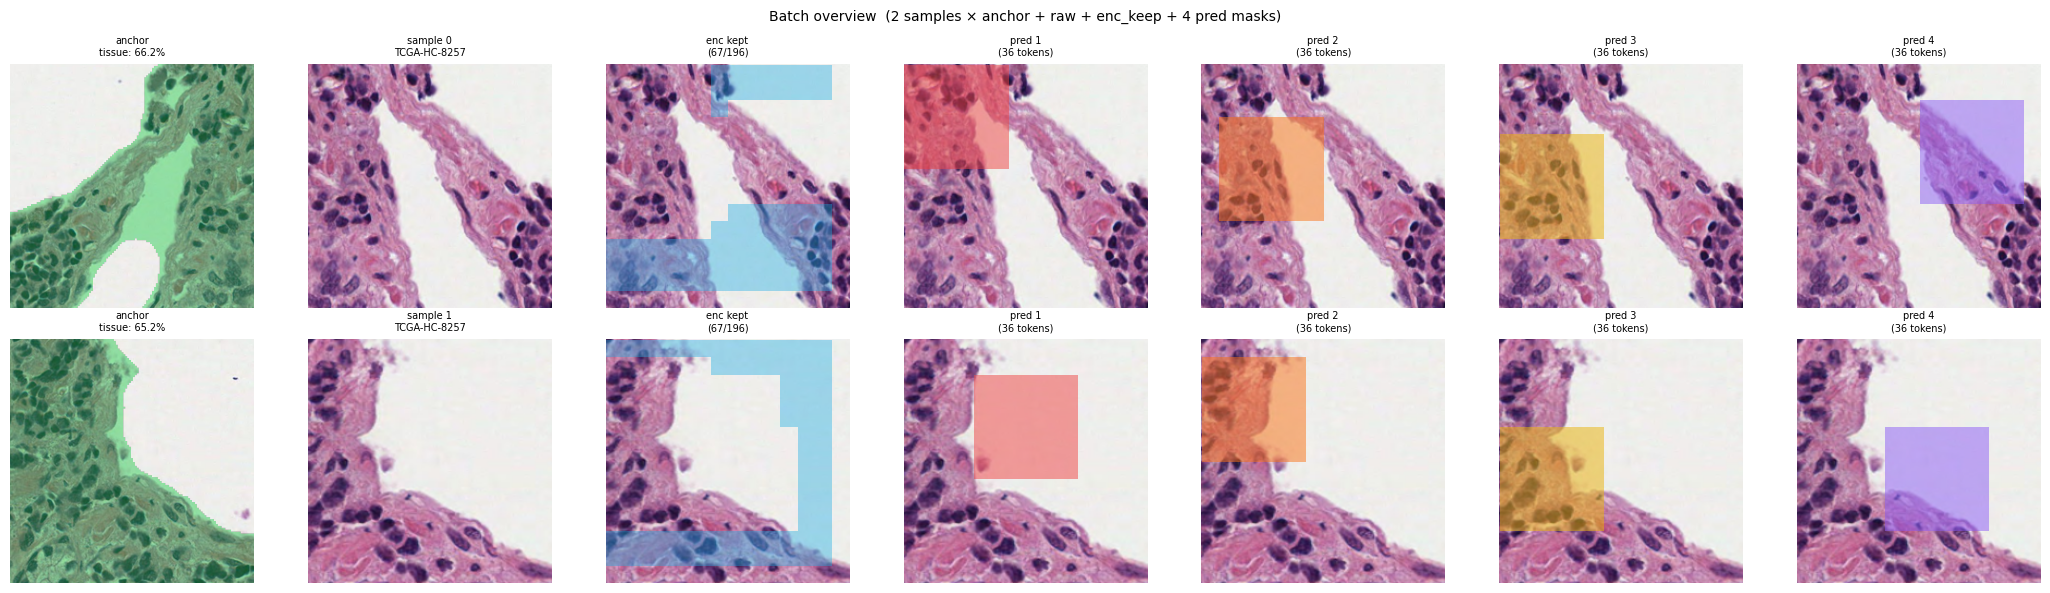

Saved: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/mpl/batch_overview.png


In [28]:
grid_h = crop_size_px // PATCH_SIZE
grid_w = crop_size_px // PATCH_SIZE

n_cols = 1 + 1 + num_enc_masks + num_pred_masks  # anchor + raw + enc_keep + pred masks
n_rows = BATCH_SIZE

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.0 * n_rows), squeeze=False)

for b in range(BATCH_SIZE):
    img_rgb = tensor_to_rgb_uint8(batch_data['image'][b])
    meta = batch_data['sample_metadata'][b]
    slide_id = meta['slide_id']
    enc_map = token_ids_to_map(masks_enc[0][b], grid_h=grid_h, grid_w=grid_w)
    pred_maps = [token_ids_to_map(pm[b], grid_h=grid_h, grid_w=grid_w) for pm in masks_pred]

    anchor_row = anchor_data_by_id[meta['anchor_id']]
    anchor_tf = float(anchor_row['tissue_fraction'])
    source_tile, mask_tile, tissue_pct = load_source_tile_and_mask(
        wsi_path=str(anchor_row['wsi_path']),
        mask_path=str(anchor_row['mask_path']),
        center_x_l0=int(anchor_row['center_x_level0']),
        center_y_l0=int(anchor_row['center_y_level0']),
        source_tile_size_px=source_tile_size_px,
        input_mpp=input_mpp,
        wsi_l0_mpp=wsi_l0_mpp_by_slide[slide_id],
    )
    record_check(
        'Anchor tissue fraction matches readback',
        abs(tissue_pct - anchor_tf) / anchor_tf < 0.05 if anchor_tf > 0 else tissue_pct < 0.05,
        f'{tissue_pct:.5f} vs anchor_row={anchor_tf:.5f}',
    )
    record_check(
        'Source tile size correct',
        source_tile.size == (source_tile_size_px, source_tile_size_px),
        f'{source_tile.size} vs expected {(source_tile_size_px, source_tile_size_px)}',
    )

    mask_arr = np.array(mask_tile)
    green_rgba = np.zeros((*source_tile.size, 4), dtype=np.uint8)
    green_rgba[mask_arr > 0] = [0, 200, 50, 100]

    col = 0

    # Anchor: source tile + tissue mask
    axes[b, col].imshow(source_tile)
    axes[b, col].imshow(green_rgba)
    axes[b, col].set_title(f"anchor\ntissue: {anchor_tf * 100:.1f}%", fontsize=7)
    axes[b, col].axis('off')
    col += 1

    # Raw model input
    axes[b, col].imshow(img_rgb)
    axes[b, col].set_title(f"sample {b}\n{slide_id}", fontsize=7)
    axes[b, col].axis('off')
    col += 1

    # Encoder keep
    axes[b, col].imshow(img_rgb)
    canonical_plot_utils.draw_mask_grid_on_image(
        axes[b, col], img_rgb, enc_map, grid_h, grid_w,
        color=canonical_plot_utils.ENC_COLOR, alpha=0.4,
    )
    axes[b, col].set_title(f"enc kept\n({int(enc_map.sum())}/{grid_h * grid_w})", fontsize=7)
    axes[b, col].axis('off')
    col += 1

    # Predictor masks
    for i, pred_map in enumerate(pred_maps):
        color = canonical_plot_utils.PRED_COLORS[i % len(canonical_plot_utils.PRED_COLORS)]
        axes[b, col].imshow(img_rgb)
        canonical_plot_utils.draw_mask_grid_on_image(
            axes[b, col], img_rgb, pred_map, grid_h, grid_w,
            color=color, alpha=0.5,
        )
        axes[b, col].set_title(f"pred {i + 1}\n({int(pred_map.sum())} tokens)", fontsize=7)
        axes[b, col].axis('off')
        col += 1

fig.suptitle(
    f'Batch overview  ({BATCH_SIZE} samples × anchor + raw + enc_keep + {num_pred_masks} pred masks)',
    fontsize=10,
)
fig.tight_layout()
batch_viz_path = MPL_DIR / 'batch_overview.png'
fig.savefig(batch_viz_path, dpi=150)
plt.show()
print(f'Saved: {batch_viz_path}')


### Tissue Coverage

Two independent concerns, kept separate:

**`tissue: X%` in title** — anchor-level quality metric from the parquet.  
Computed in `build_valid_context_anchor_catalog.py` over the full **context FOV** (`context_fov_um × context_fov_um` µm) at whatever mask spacing is available. This is a property of the anchor, not of the displayed tile.

**Col 0 — source tile + GT tissue mask overlay (green)** — visualization of what the model sees.  
The `source_tile_size_px × source_tile_size_px` tile is read from the WSI at `input_mpp` (e.g. 256 px @ 0.5 mpp = 128 µm). The mask is loaded at the closest available mask spacing, with the anchor center converted from WSI level-0 to mask level-0 pixel coordinates via `center * (wsi_l0_mpp / mask_l0_mpp)`. The coarse binary mask is upsampled with NEAREST interpolation to match the tile size.  
**Note**: `tissue: X%` and the green overlay cover *different physical regions* (context FOV vs source tile), so they will not always agree — this is expected.

**Col 1 — per-token tissue proxy heatmap**:  
`1 − luminance` of the *actual model input* (the augmented crop), aggregated to the 14 × 14 token grid.  White background → 0, stained tissue → 1.  Blue contour traces the union of all predictor-mask blocks.

**Cols 2+ — per-predictor-block coverage**:  
Same proxy heatmap with each predictor block highlighted. Title shows the mean proxy for that block.

**Summary table**: `anchor_tissue_fraction` (from parquet) vs image-derived `enc_tissue_coverage` / `pred_k_coverage`.

[PASS] Anchor tissue fraction matches readback: 0.67518 vs anchor_row=0.66211
[PASS] Source tile size correct: (256, 256) vs expected (256, 256)
[PASS] Anchor tissue fraction matches readback: 0.65243 vs anchor_row=0.65234
[PASS] Source tile size correct: (256, 256) vs expected (256, 256)


/tmp/ipykernel_1320896/2561898856.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


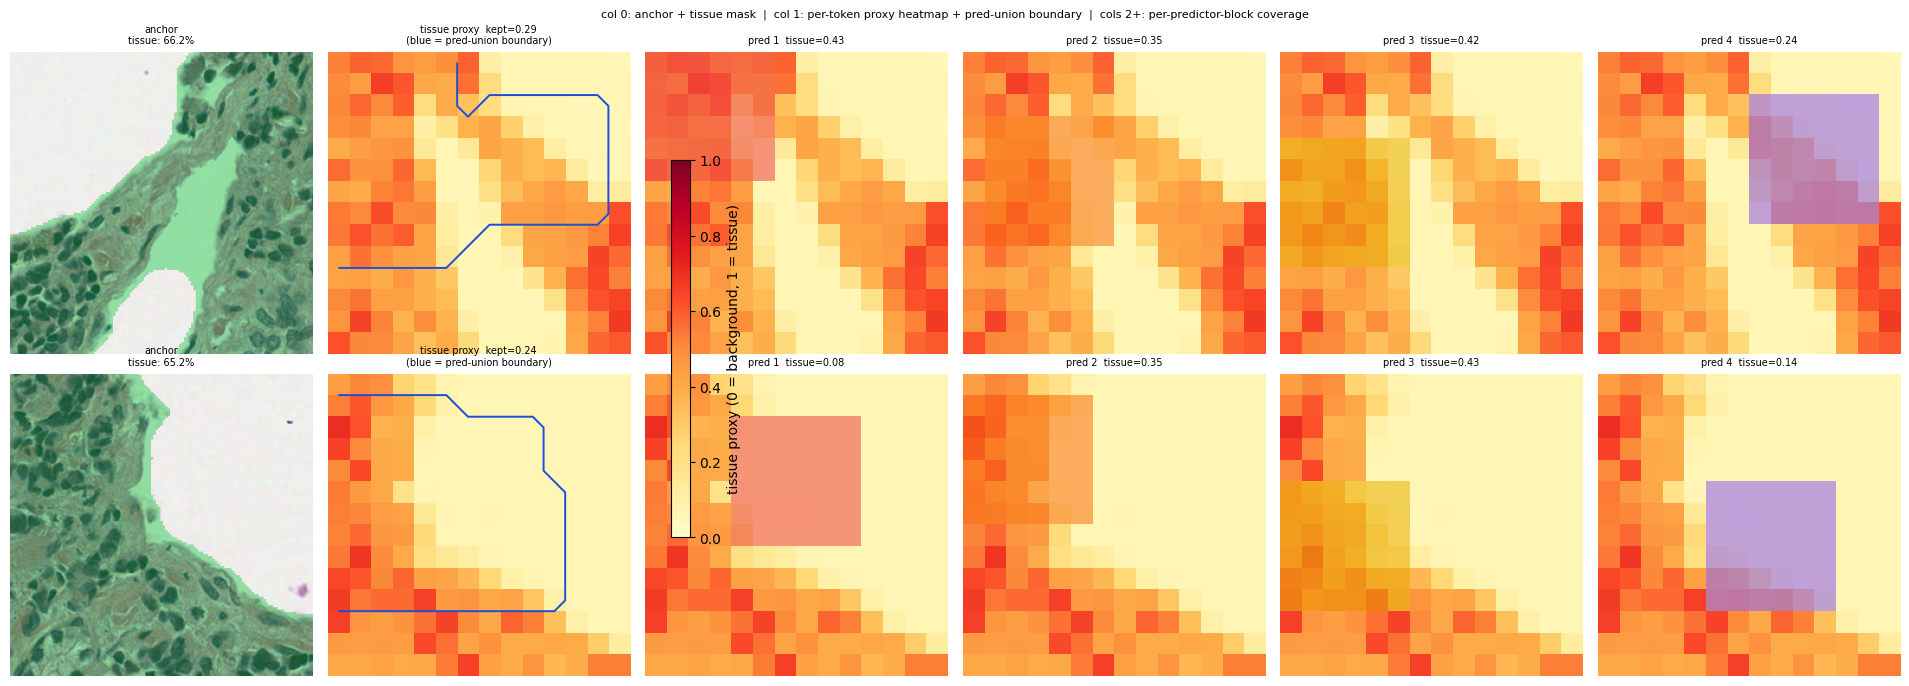

,sample,slide_id,anchor_tissue_fraction,kept_tokens_tissue,pred_1_coverage,pred_2_coverage,pred_3_coverage,pred_4_coverage
0,0,TCGA-HC-8257,0.662,0.291,0.433,0.348,0.417,0.242
1,1,TCGA-HC-8257,0.652,0.237,0.075,0.351,0.426,0.144


Saved: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/mpl/tissue_coverage.png


In [30]:
n_cols = 1 + 1 + num_pred_masks
coverage_rows = []
tissue_im_ref = None

fig, axes = plt.subplots(
    BATCH_SIZE, n_cols,
    figsize=(3.2 * n_cols, 3.5 * BATCH_SIZE),
    squeeze=False,
)

for b in range(BATCH_SIZE):
    img_t = batch_data['image'][b]
    meta = batch_data['sample_metadata'][b]
    anchor_id = meta['anchor_id']
    slide_id = meta['slide_id']

    tissue_map = compute_tissue_token_map(img_t, grid_h, grid_w, PATCH_SIZE)
    enc_map = token_ids_to_map(masks_enc[0][b], grid_h=grid_h, grid_w=grid_w)
    pred_maps = [token_ids_to_map(pm[b], grid_h=grid_h, grid_w=grid_w) for pm in masks_pred]
    pred_union_map = np.clip(sum(pred_maps), 0.0, 1.0)

    anchor_row = anchor_data_by_id[anchor_id]
    source_tile, mask_tile, tissue_pct = load_source_tile_and_mask(
        wsi_path=str(anchor_row['wsi_path']),
        mask_path=str(anchor_row['mask_path']),
        center_x_l0=int(anchor_row['center_x_level0']),
        center_y_l0=int(anchor_row['center_y_level0']),
        source_tile_size_px=source_tile_size_px,
        input_mpp=input_mpp,
        wsi_l0_mpp=wsi_l0_mpp_by_slide[slide_id],
    )

    anchor_tf = float(anchor_row['tissue_fraction'])
    record_check(
        'Anchor tissue fraction matches readback',
        abs(tissue_pct - anchor_tf) / anchor_tf < 0.05 if anchor_tf > 0 else tissue_pct < 0.05,
        f'{tissue_pct:.5f} vs anchor_row={anchor_tf:.5f}',
    )
    record_check(
        'Source tile size correct',
        source_tile.size == (source_tile_size_px, source_tile_size_px),
        f'{source_tile.size} vs expected {(source_tile_size_px, source_tile_size_px)}',
    )

    kept_coverage = float(tissue_map[enc_map > 0.5].mean()) if (enc_map > 0.5).any() else 0.0
    pred_coverages = [
        float(tissue_map[pm > 0.5].mean()) if (pm > 0.5).any() else 0.0
        for pm in pred_maps
    ]
    coverage_rows.append({
        'sample': b,
        'slide_id': slide_id,
        'anchor_tissue_fraction': round(anchor_tf, 3),
        'kept_tokens_tissue': round(kept_coverage, 3),
        **{f'pred_{i + 1}_coverage': round(c, 3) for i, c in enumerate(pred_coverages)},
    })


    # Col 0: anchor — source tile + tissue mask
    green_rgba = np.zeros((*source_tile.size, 4), dtype=np.uint8)
    mask_arr = np.array(mask_tile)
    green_rgba[mask_arr > 0] = [0, 200, 50, 100]
    axes[b, 0].imshow(source_tile)
    axes[b, 0].imshow(green_rgba)
    axes[b, 0].set_title(f"anchor\ntissue: {anchor_tf * 100:.1f}%", fontsize=7)
    axes[b, 0].axis('off')

    # Col 1: per-token tissue proxy heatmap + predictor-union boundary (blue)
    tissue_im_ref = axes[b, 1].imshow(
        tissue_map, cmap='YlOrRd', vmin=0.0, vmax=1.0, interpolation='nearest'
    )
    if pred_union_map.max() > 0.5:
        axes[b, 1].contour(pred_union_map, levels=[0.5], colors=['#1d4ed8'], linewidths=1.4)
    axes[b, 1].set_title(
        f"tissue proxy  kept={kept_coverage:.2f}\n(blue = pred-union boundary)", fontsize=7
    )
    axes[b, 1].axis('off')

    # Cols 2…n: tissue heatmap + each predictor block highlighted
    for i, (pm, cov) in enumerate(zip(pred_maps, pred_coverages)):
        col = 2 + i
        color_hex = canonical_plot_utils.PRED_COLORS[i % len(canonical_plot_utils.PRED_COLORS)]
        r = int(color_hex[1:3], 16) / 255.0
        gv = int(color_hex[3:5], 16) / 255.0
        bv = int(color_hex[5:7], 16) / 255.0
        axes[b, col].imshow(tissue_map, cmap='YlOrRd', vmin=0.0, vmax=1.0, interpolation='nearest')
        overlay = np.zeros((grid_h, grid_w, 4), dtype=np.float32)
        overlay[pm > 0.5] = [r, gv, bv, 0.55]
        axes[b, col].imshow(overlay, interpolation='nearest')
        axes[b, col].set_title(f"pred {i + 1}  tissue={cov:.2f}", fontsize=7)
        axes[b, col].axis('off')

if tissue_im_ref is not None:
    plt.colorbar(
        tissue_im_ref, ax=list(axes[:, 1]),
        label='tissue proxy (0 = background, 1 = tissue)',
        shrink=0.7, pad=0.04,
    )

fig.suptitle(
    'col 0: anchor + tissue mask  '
    '|  col 1: per-token proxy heatmap + pred-union boundary  '
    '|  cols 2+: per-predictor-block coverage',
    fontsize=8,
)
fig.tight_layout()

tissue_viz_path = MPL_DIR / 'tissue_coverage.png'
fig.savefig(tissue_viz_path, dpi=150)
plt.show()

if pd is not None:
    display(pd.DataFrame(coverage_rows))
else:
    for row in coverage_rows:
        print(row)

print(f'Saved: {tissue_viz_path}')


## Mask Non-Leakage and Token Geometry Checks

Checks:
- `encoder_keep_tokens ∩ predictor_union_tokens == ∅` (non-leakage invariant)
- Token counts are in expected ranges
- Visual overlay of encoder-keep and predictor masks on the sample image

Token grid: 14x14 = 196 tokens
[PASS] Non-leakage: encoder keep ∩ predictor union == empty: overlap_tokens=0
Encoder kept: 67/196 tokens
Predictor union: 102/196 tokens
  pred mask 1: 36 tokens
  pred mask 2: 36 tokens
  pred mask 3: 36 tokens
  pred mask 4: 36 tokens


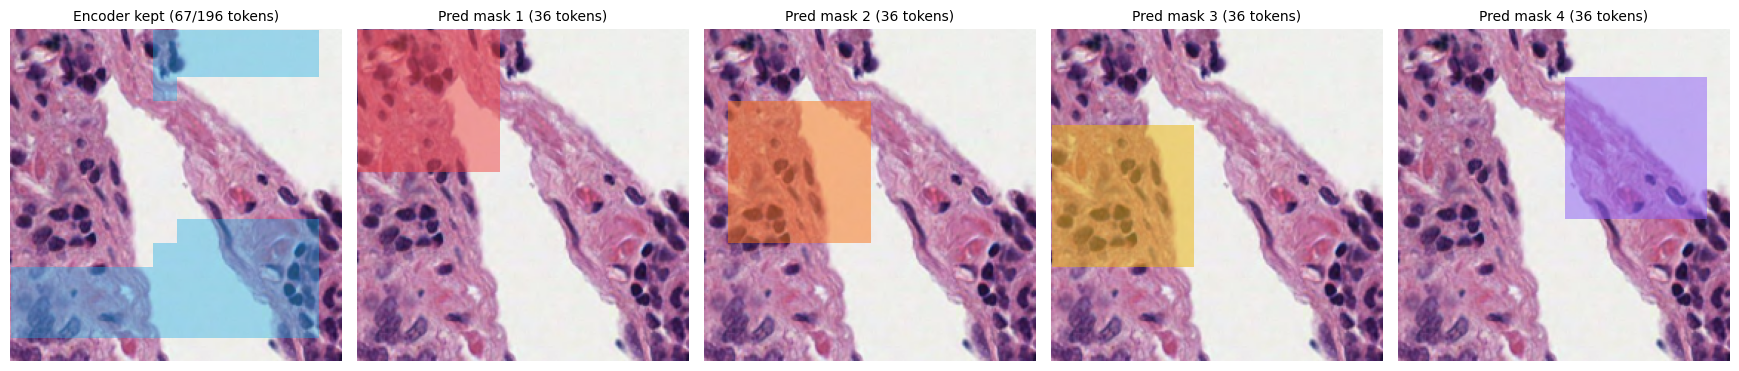

[PASS] Mask visualization written: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/mpl/mask_geometry_sample0.png


In [31]:
sample_idx = 0
grid_h = crop_size_px // PATCH_SIZE
grid_w = crop_size_px // PATCH_SIZE
total_tokens = grid_h * grid_w

print(f'Token grid: {grid_h}x{grid_w} = {total_tokens} tokens')

enc_tokens = set(masks_enc[0][sample_idx].detach().cpu().tolist())
pred_token_sets = [set(pm[sample_idx].detach().cpu().tolist()) for pm in masks_pred]
pred_union = set().union(*pred_token_sets)
leak_overlap = sorted(enc_tokens & pred_union)

record_check(
    'Non-leakage: encoder keep ∩ predictor union == empty',
    len(leak_overlap) == 0,
    f'overlap_tokens={len(leak_overlap)}',
)

print(f'Encoder kept: {len(enc_tokens)}/{total_tokens} tokens')
print(f'Predictor union: {len(pred_union)}/{total_tokens} tokens')
for i, ps in enumerate(pred_token_sets):
    print(f'  pred mask {i + 1}: {len(ps)} tokens')

# Visualize encoder-keep and predictor masks overlaid on the sample image
img_rgb0 = tensor_to_rgb_uint8(batch_data['image'][sample_idx])
fig = canonical_plot_utils.plot_canonical_masks(
    image_rgb=img_rgb0,
    masks_enc=masks_enc,
    masks_pred=masks_pred,
    grid_h=grid_h,
    grid_w=grid_w,
    sample_idx=sample_idx,
)
mask_viz_path = MPL_DIR / 'mask_geometry_sample0.png'
fig.savefig(mask_viz_path, dpi=170)
plt.show()

record_check('Mask visualization written', mask_viz_path.exists(), str(mask_viz_path))

## QC Summary

Consolidate all checks and fail if any critical check did not pass.

In [32]:
if pd is not None:
    qc_df = pd.DataFrame(QC_RESULTS)
    display(qc_df)
else:
    for row in QC_RESULTS:
        state = 'PASS' if row['passed'] else 'FAIL'
        print(f"[{state}] {row['check']}: {row['details']}")

failed = [r for r in QC_RESULTS if not bool(r['passed'])]
assert not failed, f'QC failed with {len(failed)} failing checks: {failed}'

print(f'\nAll critical QC checks passed: {len(QC_RESULTS)} checks')
print('Artifacts:')
print(f'- Manifest CSV: {MANIFEST_CSV}')
print(f'- Slide metadata parquet: {SLIDE_METADATA_PARQUET}')
print(f'- Anchor manifest: {ANCHOR_MANIFEST_JSON}')
print(f'- Sample image: {sample_viz_path}')
print(f'- Mask visualization: {mask_viz_path}')

,check,passed,details
0,Path exists: wsi,True,/data/pathology/projects/clement/code/ijepath/...
1,Path exists: tissue-masks,True,/data/pathology/projects/clement/code/ijepath/...
2,Path exists: canonical_20x_256_224.yaml,True,/data/pathology/projects/clement/code/ijepath/...
3,Path exists: canonical_pathorob_camelyon.yaml,True,/data/pathology/projects/clement/code/ijepath/...
4,At least one matched slide/mask pair,True,matched=4
...,...,...,...
85,Source tile size correct,True,"(256, 256) vs expected (256, 256)"
86,Anchor tissue fraction matches readback,True,0.65243 vs anchor_row=0.65234
87,Source tile size correct,True,"(256, 256) vs expected (256, 256)"
88,Non-leakage: encoder keep ∩ predictor union ==...,True,overlap_tokens=0



All critical QC checks passed: 90 checks
Artifacts:
- Manifest CSV: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/manifests/slides_with_tissue_masks.csv
- Slide metadata parquet: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/slide_metadata.parquet
- Anchor manifest: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/indexes/anchor_catalog_manifest.json
- Sample image: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/mpl/sample0_canonical.png
- Mask visualization: /data/pathology/projects/clement/code/ijepath/output/notebook-artifacts/canonical-manifest-to-batch-qc/mpl/mask_geometry_sample0.png
